In [21]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

## Experiment 1: Binary vs B-tree Query Throughput

Setup:
- Uniformly random point queries
- Buffer pool: 1MB (256 frames)
- 50K queries at each data size
- Data sizes: 50K to 1M entries

In [22]:
# compile and run experiment 1
import os
# get Part3 dir relative to notebook location
notebook_dir = os.path.dirname(os.path.abspath('experiments.ipynb'))
part3_dir = os.path.dirname(notebook_dir) if notebook_dir.endswith('experiments') else notebook_dir
os.chdir(part3_dir)
subprocess.run(['make', 'experiments/experiment'], check=True)
result = subprocess.run(['./experiments/experiment', '1'], capture_output=True, text=True)
print(result.stdout)

g++ -Wall -Wextra -std=c++17 -g -c experiments/experiment.cpp -o experiments/experiment.o
g++ -Wall -Wextra -std=c++17 -g -c buffer_pool.cpp -o buffer_pool.o
g++ -Wall -Wextra -std=c++17 -g -o experiments/experiment experiments/experiment.o buffer_pool.o xxhash.o
=== Experiment 1: Binary vs B-tree ===
data_size,binary_throughput,btree_throughput
50000,291897,997915
100000,271453,833099
150000,35034.4,69263.4
200000,11430.8,27046.1
250000,6945.34,20240.2
300000,5586.24,17193.9
350000,4871.65,15494.1
400000,4250.51,14484.8



In [23]:
# parse output
lines = result.stdout.strip().split('\n')
csv_data = '\n'.join(lines[1:])  # skip header line
df1 = pd.read_csv(StringIO(csv_data))
df1

,data_size,binary_throughput,btree_throughput
0,50000,291897.00,997915.0
1,100000,271453.00,833099.0
2,150000,35034.40,69263.4
3,200000,11430.80,27046.1
4,250000,6945.34,20240.2
5,300000,5586.24,17193.9
6,350000,4871.65,15494.1
7,400000,4250.51,14484.8


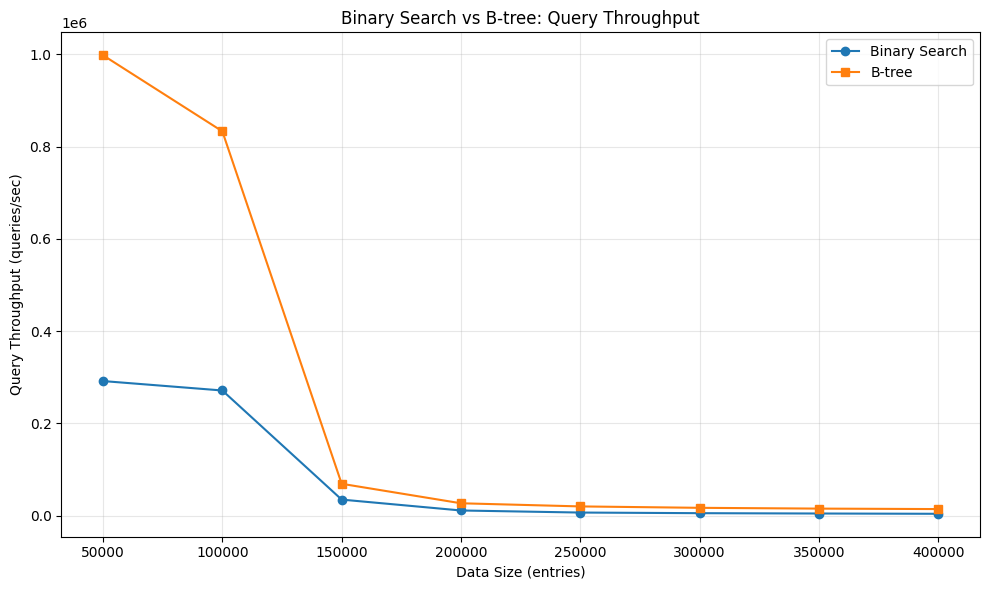

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(df1['data_size'], df1['binary_throughput'], 'o-', label='Binary Search')
plt.plot(df1['data_size'], df1['btree_throughput'], 's-', label='B-tree')
plt.xlabel('Data Size (entries)')
plt.ylabel('Query Throughput (queries/sec)')
plt.title('Binary Search vs B-tree: Query Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp1_throughput.png', dpi=150)
plt.show()

## Experiment 2: Throughput Over 1GB Insertion

Setup:
- Buffer pool: 10MB
- Bloom filter: 8 bits per entry
- Memtable: 1MB
- Total data: 1GB
- Measurements every 100MB

In [25]:
# run experiment 2 (takes a while)
result2 = subprocess.run(['./experiments/experiment', '2'], capture_output=True, text=True)
print(result2.stdout)


=== Experiment 2: Throughput over 1GB insertion ===
data_mb,insert_throughput,get_throughput,scan_throughput
100,203869,1942.05,597602
200,121462,1488.76,425733
300,120779,1399.85,445427
400,204660,1206.26,150532
500,121462,1187.81,159364
600,121570,1174.69,170190
700,127224,1116.05,147106
800,193175,1052.14,86285.5
900,121281,1048.12,98483.4
1000,126237,1007.08,90885.7



In [26]:
# parse output
lines = result2.stdout.strip().split('\n')
csv_start = next(i for i, l in enumerate(lines) if 'data_mb' in l)
csv_data = '\n'.join(lines[csv_start:])
df2 = pd.read_csv(StringIO(csv_data))
df2

,data_mb,insert_throughput,get_throughput,scan_throughput
0,100,203869,1942.05,597602.0
1,200,121462,1488.76,425733.0
2,300,120779,1399.85,445427.0
3,400,204660,1206.26,150532.0
4,500,121462,1187.81,159364.0
5,600,121570,1174.69,170190.0
6,700,127224,1116.05,147106.0
7,800,193175,1052.14,86285.5
8,900,121281,1048.12,98483.4
9,1000,126237,1007.08,90885.7


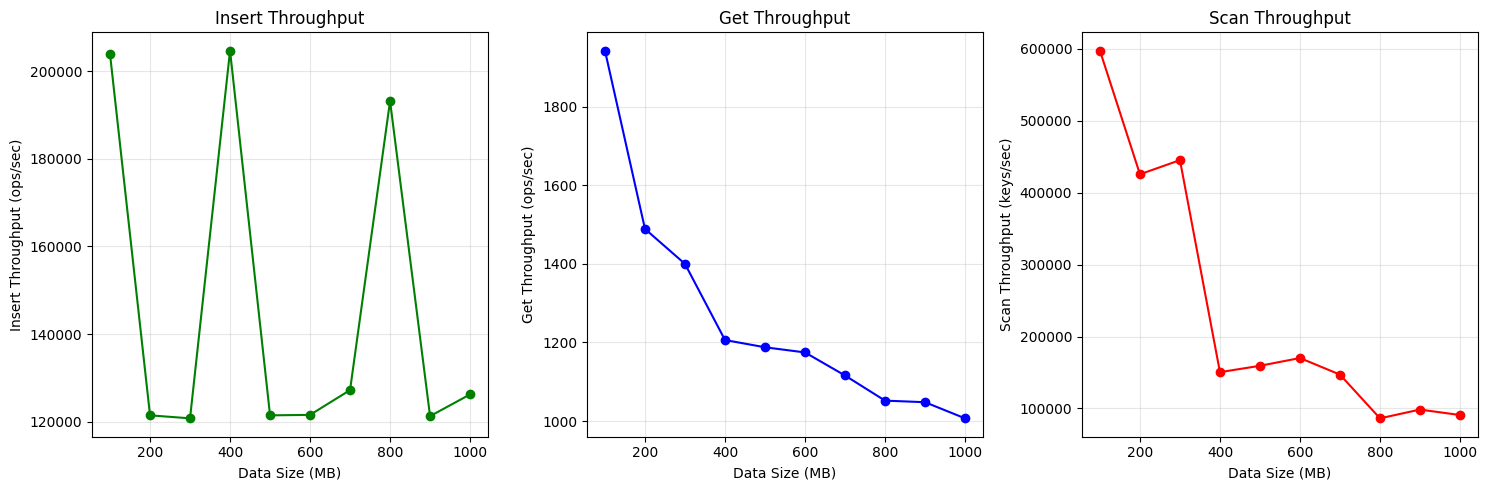

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(df2['data_mb'], df2['insert_throughput'], 'g-o')
axes[0].set_xlabel('Data Size (MB)')
axes[0].set_ylabel('Insert Throughput (ops/sec)')
axes[0].set_title('Insert Throughput')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df2['data_mb'], df2['get_throughput'], 'b-o')
axes[1].set_xlabel('Data Size (MB)')
axes[1].set_ylabel('Get Throughput (ops/sec)')
axes[1].set_title('Get Throughput')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df2['data_mb'], df2['scan_throughput'], 'r-o')
axes[2].set_xlabel('Data Size (MB)')
axes[2].set_ylabel('Scan Throughput (keys/sec)')
axes[2].set_title('Scan Throughput')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_throughput.png', dpi=150)
plt.show()